h = 0.1           |λ| = 99.0000  -> BLEW UP at t≈0.500
h = 0.01          |λ| = 9.0000  -> BLEW UP at t≈0.100
h = 0.001         |λ| = 0.0000  -> Stable


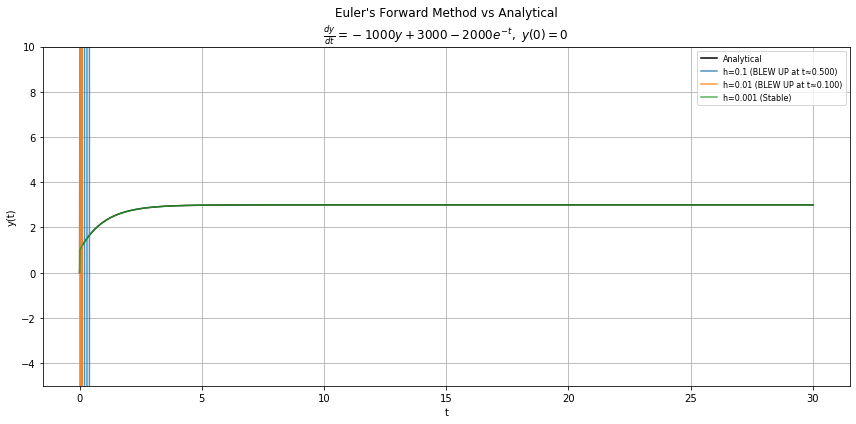

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)
def analytical(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)
t_start, t_end = 0, 30
step_sizes = [0.1, 0.01, 0.001]
t_exact = np.linspace(t_start, t_end, 1000)
y_exact = analytical(t_exact)
plt.figure(figsize=(12, 6))
plt.plot(t_exact, y_exact, 'k-', label='Analytical')
for h in step_sizes:
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = 0.0
    blown = False
    for i in range(1, len(t_values)):
        y_new = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        if not np.isfinite(y_new) or abs(y_new) > 1e10:
            blown = True
            t_values = t_values[:i]
            y_values = y_values[:i]
            break
        y_values[i] = y_new
    eig_mag = abs(1 - 1000 * h)
    status = f"BLEW UP at t≈{t_values[-1]:.3f}" if blown else "Stable"
    print(f"h = {h:<12}  |λ| = {eig_mag:.4f}  -> {status}")
    plt.plot(t_values, y_values, label=f'h={h} ({status})', alpha=0.8)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Euler's Forward Method vs Analytical\n"
          r"$\frac{dy}{dt} = -1000y + 3000 - 2000e^{-t},\ y(0)=0$")
plt.ylim(-5, 10)
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

#Green is ploted but the black line overlaps it